# El Qang (qg) y la criptografía: qué aplica y qué no

Este notebook separa la línea de criptografía del resto del proyecto. Reproduce, en versiones rápidas, las secciones §40 (BB84) y §41 (generador cuántico de números aleatorios) de `RESEARCH_NOTES.md`, con los scripts del repositorio.

**Lo primero, sin vueltas:**

* **Criptografía post-cuántica** (ML-KEM/Kyber, ML-DSA/Dilithium, esquemas basados en retículos o en hashes): son algoritmos **clásicos**, pensados para resistir a una computadora cuántica. No hay qubits ni mediciones: **qg no aplica**. Tampoco ayuda a la amenaza (Shor contra RSA).
* **Criptografía cuántica** (distribución de claves BB84, números aleatorios cuánticos): lo que se mide son justamente $qg_Z$ y $qg_X$. Acá qg sí da herramientas medibles, **de diagnóstico**, no de seguridad nueva.

**Contenido**

1. BB84: ¿espía o ruido natural? (§40)
2. BB84 con claves finitas (§43)
3. Números aleatorios certificados (QRNG) (§41)
4. QRNG en el simulador con ruido de IonQ (§42)
5. Resumen honesto

In [1]:
import os, sys, subprocess
if not os.path.exists("qang") and not os.path.exists("../examples"):
    subprocess.run(["git", "clone", "-q", "https://github.com/Viny2030/qang"], check=True)
ROOT = "qang" if os.path.exists("qang") else ".."
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "numpy", "scipy", "matplotlib"], check=True)
sys.path.insert(0, os.path.abspath(os.path.join(ROOT, "examples")))
import numpy as np
from IPython.display import Image, display
EX = os.path.abspath(os.path.join(ROOT, "examples"))
print("listo")

listo


## 1. BB84: ¿espía o ruido natural? (§40)

En BB84, Alice envía $|0\rangle, |1\rangle$ (base Z) o $|+\rangle, |-\rangle$ (base X) y Bob mide. Cada estado enviado da un valor qg en la recepción:

$$qg(0) = 1 - 2e(0\to1), \qquad qg(1) = -1 + 2e(1\to0),$$

y la suma $A_Z = qg(0) + qg(1) = 2\,[e(1\to0) - e(0\to1)]$ es el **testigo de T1** de §24:

* el deterioro natural de un qubit guardado (T1) produce solo errores $1\to0$: $A_Z$ **sube**;
* un espía que intercepta y reenvía produce errores **simétricos**: $A_Z$ **no se mueve**.

Canal de base: T1 $\gamma_0 = 0.02$, desfase $p_0 = 0.01$, detector con error asimétrico ($e_{01} = 0.005$, $e_{10} = 0.01$).

In [2]:
import bb84_qg_eve_vs_noise as B
print(f"{'escenario':30s} {'e(0->1)':>8} {'e(1->0)':>8} {'QBER_Z':>7} {'A_Z':>7} {'clave':>6}")
for name, kw in B.SCENARIOS:
    e = B.error_probabilities(**kw); qz, qx = B.qber(e)
    print(f"{name:30s} {e[0]:8.4f} {e[1]:8.4f} {qz:7.4f} {B.z_asymmetry(e):+7.4f} {B.shor_preskill(qz, qx):6.3f}")

escenario                       e(0->1)  e(1->0)  QBER_Z     A_Z  clave
baseline                         0.0050   0.0297  0.0174 +0.0494  0.720
T1 drift, gamma 0.04             0.0050   0.0494  0.0272 +0.0888  0.640
T1 drift, gamma 0.06             0.0050   0.0691  0.0370 +0.1282  0.567
intercept-resend f=0.02          0.0098   0.0345  0.0222 +0.0494  0.668
intercept-resend f=0.05          0.0171   0.0418  0.0294 +0.0494  0.594
intercept-resend f=0.10          0.0291   0.0538  0.0415 +0.0494  0.481
intercept-resend f=0.20          0.0533   0.0780  0.0656 +0.0494  0.285
T1-mimicking attack, +0.04       0.0050   0.0691  0.0370 +0.1282  0.567


Ahora los dos monitores, con ventanas de 2000 bits comparados y 1% de falsas alarmas en la situación normal: el **monitor de QBER** (el estándar: mira el total de errores) y el **monitor qg** (usa los cuatro tipos de error y exige que un "ataque" explique los datos mejor que "normal" y que "deterioro de T1").

escenario                         QBER      qg   (tasa de alarmas)


baseline                         0.003   0.010


T1 drift, gamma 0.04             0.503   0.007


T1 drift, gamma 0.06             0.970   0.007


intercept-resend f=0.02          0.247   0.333


intercept-resend f=0.05          0.883   0.850


intercept-resend f=0.10          1.000   1.000


intercept-resend f=0.20          1.000   1.000


T1-mimicking attack, +0.04       0.970   0.007


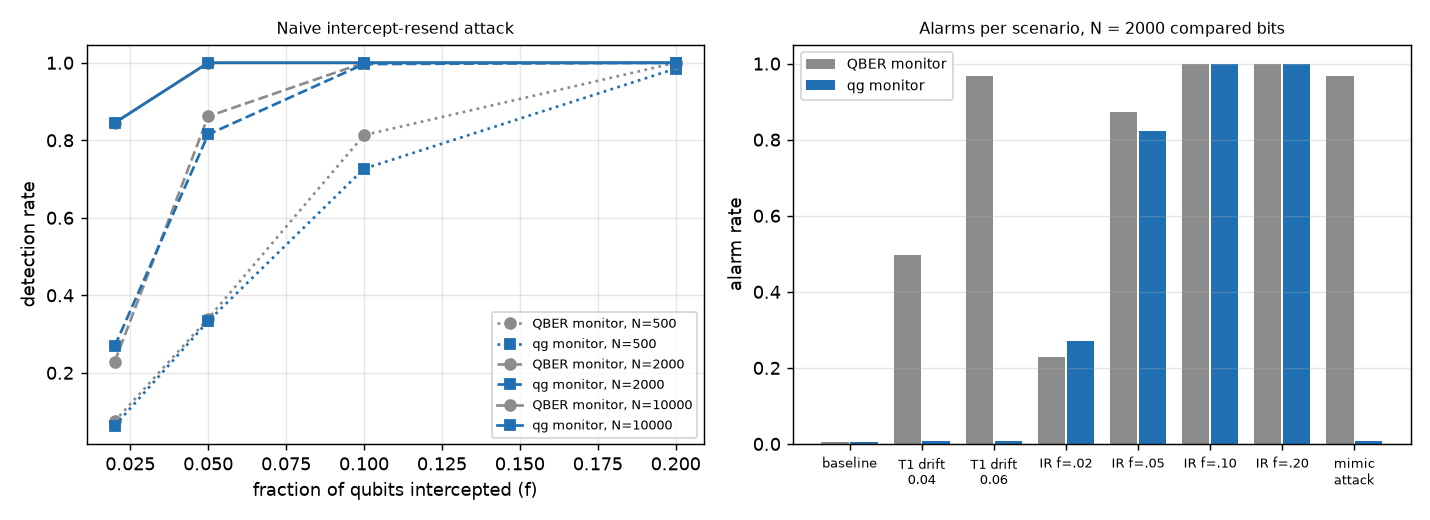

In [3]:
th = B.calibrate_thresholds(2000, reps=800)
print(f"{'escenario':30s} {'QBER':>7} {'qg':>7}   (tasa de alarmas)")
for name, kw in B.SCENARIOS:
    a, b = B.alarm_rates(B.error_probabilities(**kw), 2000, th, reps=300)
    print(f"{name:30s} {a:7.3f} {b:7.3f}")
display(Image(os.path.join(EX, "bb84_qg_eve_vs_noise.png"), width=900))

**Lectura.**

* **A favor:** el monitor qg detecta al espía que intercepta y reenvía igual que el estándar, y **no da falsas alarmas cuando el hardware se deteriora** (T1), donde el monitor de QBER se dispara casi siempre.
* **El costo, por diseño:** un espía que imite exactamente a T1 pasa inadvertido para el monitor qg (el de QBER sí lo ve). Hay que usar **los dos juntos**: QBER dice "algo cambió", qg dice "qué tipo de cambio".
* **No mejora la seguridad:** la fracción de clave secreta baja igual en ambos casos; una prueba de seguridad debe atribuir todo error al espía.
* **Dónde aplica:** enlaces con qubits de materia (memorias, iones, superconductores) o demostraciones en chip; no en fibra con fotones polarizados, cuyo ruido es casi simétrico.

## 2. BB84 con claves finitas (§43)

En un enlace real la clave se destila en **bloques finitos**. Usamos la cota de Tomamichel, Lim, Gisin y Renner (2012): $n$ bits de clave en Z, $k$ bits de prueba en X; el protocolo aborta si el error de prueba supera una tolerancia $Q_{\rm tol}$ fijada de antemano, y

$$\ell = n\,[1 - h(Q_{\rm tol} + \mu)] - 1.1\,n\,h(Q_Z) - \log_2\frac{2}{\varepsilon_{\rm sec}^2\varepsilon_{\rm cor}}, \qquad \mu = \sqrt{\tfrac{n+k}{nk}\,\tfrac{k+1}{k}\,\ln\tfrac{2}{\varepsilon_{\rm sec}}}.$$

**Dónde entra qg, sin costo de clave:** después de la corrección de errores Bob conoce los bits de Alice, así que tiene los cuatro conteos de error (los cuatro valores qg de §40) sobre **todos** los $n$ bits, sin revelar nada. Con ellos calculamos dos banderas: "tipo ataque" (error simétrico más allá de cualquier T1) y "tipo deriva" (T1 por encima de lo normal, haya o no ataque).

escenario                         1e+04    1e+05    1e+06  asintótico


baseline                          0.120    0.268    0.407     0.707


T1 drift 0.06                     0.068    0.182    0.294     0.544


intercept f = 0.05                0.079    0.201    0.318     0.575



Protocolo ajustado al caso normal con n = 10^4 (k = 3353, Q_tol = 2.87%), 150 bloques:
escenario                       aborta  ataque  deriva
baseline                          0.00    0.01    0.01
T1 drift 0.03                     0.08    0.01    0.85
T1 drift 0.04                     0.23    0.03    1.00
T1 drift 0.06                     0.82    0.05    1.00
intercept f = 0.02                0.20    0.99    0.00
intercept f = 0.05                0.96    1.00    0.01
drift 0.04 + intercept 0.02       0.82    0.99    1.00
T1-mimicking attack               0.86    0.05    1.00


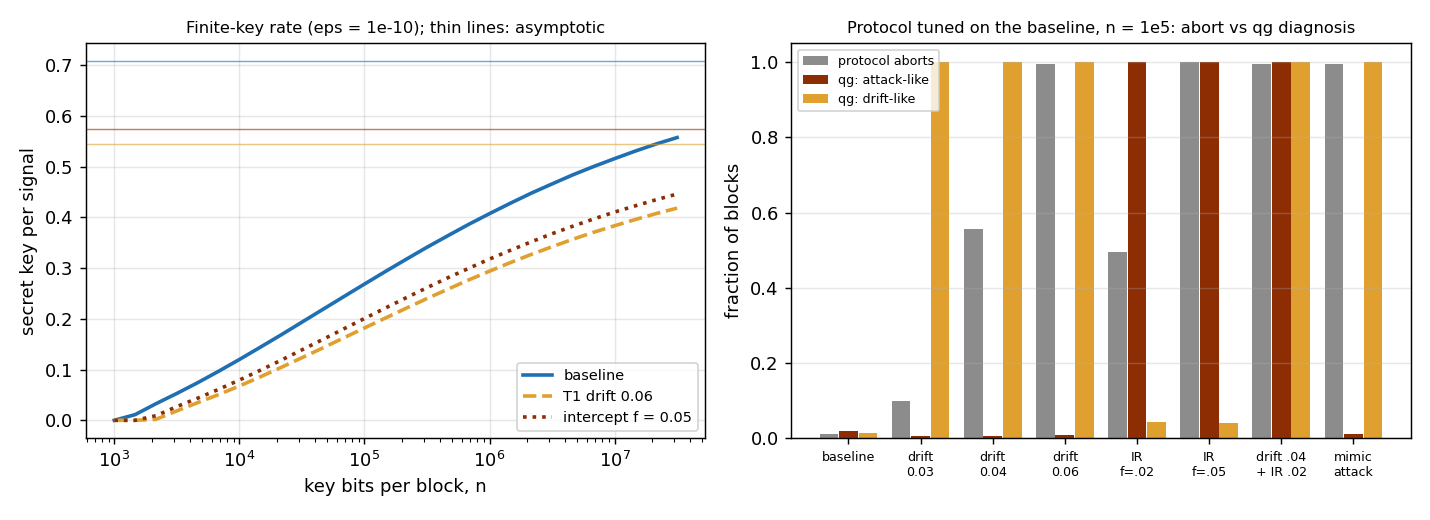

In [4]:
import bb84_finite_key_qg as F
print(f"{'escenario':30s} " + " ".join(f"{n:>8.0e}" for n in (1e4, 1e5, 1e6)) + "  asintótico")
for name in ("baseline", "T1 drift 0.06", "intercept f = 0.05"):
    _, qz, qx = F.channel(**dict(F.SCENARIOS)[name])
    print(f"{name:30s} " + " ".join(f"{F.optimize(n, qz, qx)[0]:8.3f}" for n in (1e4, 1e5, 1e6)) + f"  {F.asymptotic_rate(qz, qx):8.3f}")
d = F.diagnose(10000, reps=150)
print(f"\nProtocolo ajustado al caso normal con n = 10^4 (k = {d['k']}, Q_tol = {100*d['q_tol']:.2f}%), 150 bloques:")
print(f"{'escenario':30s} {'aborta':>7} {'ataque':>7} {'deriva':>7}")
for name, _ in F.SCENARIOS:
    v = d[name]
    print(f"{name:30s} {v['abort']:7.2f} {v['attack']:7.2f} {v['drift']:7.2f}")
display(Image(os.path.join(EX, "bb84_finite_key_qg.png"), width=900))

**Lectura.**

* **Las claves finitas cuestan:** con $10^4$ bits por bloque se conserva el 17% de la tasa asintótica; con $10^5$, el 38%; con $10^6$, el 58%. Por debajo de ~1200 bits no hay clave.
* **A favor:** un aborto no dice *por qué*; las banderas qg sí. Con $10^5$ bits la atribución es prácticamente exacta: todo bloque con deriva de T1 queda marcado como deriva (aborte o no), todo bloque con espía como ataque, incluida la mitad que no abortó. Y un **ataque escondido bajo la deriva** (espía pequeño sobre una memoria que se deteriora) levanta las dos banderas; el monitor de §40 no lo veía.
* **Alerta temprana:** con deriva leve solo aborta el 10% de los bloques, pero la bandera de deriva está arriba en todos: se puede recalibrar antes de que el enlace se caiga.
* **En contra / límites:** la longitud de clave es la estándar; qg no la mejora, y todo error se sigue cargando al espía. Un espía que imite T1 exactamente queda marcado como "deriva", por construcción. Solo se modelan dos familias de error.

## 3. Números aleatorios certificados (§41)

Un generador cuántico prepara $|+\rangle$ y mide Z. Con desfase (T2) o población térmica (§31), la salida **sigue pareciendo** aleatoria, pero esa aleatoriedad pasa a ser ruido clásico que un adversario que controla el entorno puede conocer. Con medición confiable y un adversario que tiene la purificación, la aleatoriedad privada por disparo es

$$H_{\min}(Z|E) = -\log_2 \frac{1 + \sqrt{1 - r_\perp^2}}{2}, \qquad r_\perp = \sqrt{qg_X^2 + qg_Y^2},$$

que **no depende de** $qg_Z$: solo cuenta la coherencia en la base medida. Se compara el estimador habitual (sesgo de la salida) con los estimadores qg (rondas de prueba en X e Y, con y sin la calibración de lectura de §31).

escenario                      verdad |          naive |   qg one-sided |   qg +/- pairs |  qg calibrated
ideal |+>, ideal readout        1.000 |  0.994 (0.00) |  0.686 (0.00) |  0.686 (0.00) |  0.686 (0.00)
ideal |+>, §31 readout          1.000 |  0.964 (0.00) |  0.578 (0.00) |  0.511 (0.00) |  0.679 (0.00)
T2: V = 0.8                     0.322 |  0.965 (1.00) |  0.269 (0.00) |  0.245 (0.00) |  0.286 (0.00)
T2: V = 0.5                     0.100 |  0.964 (1.00) |  0.086 (0.00) |  0.077 (0.00) |  0.087 (0.00)
T2: V = 0.2                     0.015 |  0.964 (1.00) |  0.013 (0.09) |  0.009 (0.00) |  0.010 (0.00)
thermal p = 0.05, V = 0.9       0.334 |  0.965 (1.00) |  0.279 (0.00) |  0.254 (0.00) |  0.297 (0.00)
strong readout asymmetry        0.608 |  0.876 (1.00) |  0.499 (0.00) |  0.342 (0.00) |  0.515 (0.00)
(entre paréntesis: fracción de corridas por ENCIMA de la verdad = inseguras)


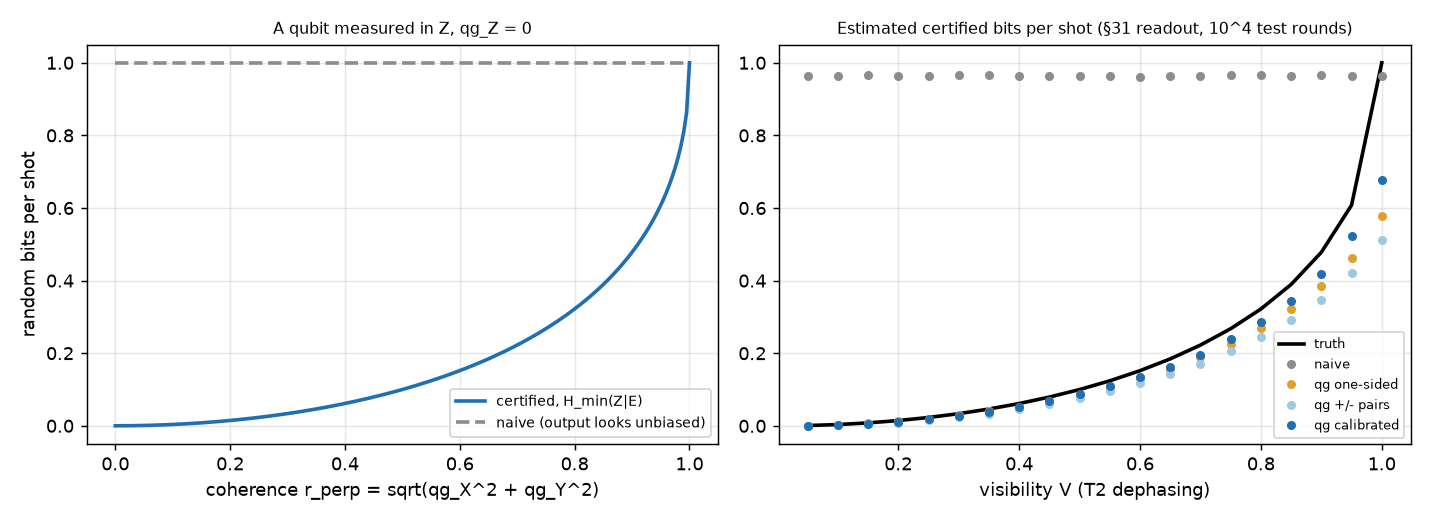

In [5]:
import qrng_qg_certified as Q
t = Q.table(n_test=10000, reps=150)
print(f"{'escenario':30s} {'verdad':>6} | " + " | ".join(f"{e:>14s}" for e in Q.ESTIMATORS))
for name, _, _ in Q.SCENARIOS:
    r = t[name]
    print(f"{name:30s} {r['truth']:6.3f} | " + " | ".join(f"{r[e][0]:6.3f} ({r[e][1]:.2f})" for e in Q.ESTIMATORS))
print("(entre paréntesis: fracción de corridas por ENCIMA de la verdad = inseguras)")
display(Image(os.path.join(EX, "qrng_qg_certified.png"), width=900))

**Lectura.**

* **A favor:** el estimador habitual es **inseguro** en cuanto el estado no es puro (con visibilidad 0.2 certifica 0.97 bits por disparo cuando solo 0.015 son privados). El estimador qg es **seguro en todas las corridas** si cada eje se mide con las dos rotaciones, y la calibración de §31 recupera 10–50% más bits certificados.
* **En contra / límites:** cerca de una fuente perfecta certificar cuesta muchos disparos (la pendiente infinita en $r_\perp = 1$ es otra vez el polo de qg); es un QRNG dependiente del dispositivo (medición confiable), no independiente del dispositivo; la fórmula es estándar y qg la escribe en cantidades medidas.

## 4. QRNG en el simulador con ruido de IonQ (§42)

Lo mismo, pero con modelos de ruido de iones atrapados (aria-1 y forte-1) en el simulador gratuito de IonQ, y con una **fuga real**: un segundo ion, el "entorno", aprende el valor de salida mediante una compuerta MS parcial de ángulo $\theta$. La salida sigue siendo una moneda equilibrada, pero la aleatoriedad privada cae a $H_{\min}$ con $r = |\cos 2\pi\theta|$.

Las corridas ya están grabadas en `examples/data/ionq_sim_results.json` (132 trabajos, 3 repeticiones por modelo), así que esta celda **no necesita clave de IonQ**: solo lee y resume.

In [6]:
import json
import qrng_qg_certified as Q
rec = json.load(open(os.path.join(EX, "data", "ionq_sim_results.json"), encoding="utf-8"))
for noise in ("aria-1", "forte-1"):
    runs = [rec[k] for k in sorted(rec) if k.startswith(f"ionq_sim|{noise}|qrng|")]
    print(f"--- {noise} ({len(runs)} corridas), lectura b = {np.mean([r['readout_b'] for r in runs]):.4f}")
    print(f"{'theta':>6} {'verdad':>6} | " + " | ".join(f"{e:>14s}" for e in Q.ESTIMATORS))
    for t in runs[0]["rows"]:
        rs = [r["rows"][t] for r in runs]
        cells = [f"{np.mean([x[e] for x in rs]):6.3f} ({np.mean([x[e] > x['truth'] + 1e-9 for x in rs]):.2f})" for e in Q.ESTIMATORS]
        print(f"{float(t):6.2f} {rs[0]['truth']:6.3f} | " + " | ".join(cells))
print("(entre paréntesis: fracción de corridas por ENCIMA de la verdad = inseguras)")

--- aria-1 (3 corridas), lectura b = 0.9999
 theta verdad |          naive |   qg one-sided |   qg +/- pairs |  qg calibrated
  0.00  1.000 |  0.984 (0.00) |  0.686 (0.00) |  0.728 (0.00) |  0.729 (0.00)
  0.04  0.680 |  0.989 (1.00) |  0.529 (0.00) |  0.557 (0.00) |  0.557 (0.00)
  0.08  0.433 |  0.983 (1.00) |  0.370 (0.00) |  0.382 (0.00) |  0.382 (0.00)
  0.12  0.248 |  0.996 (1.00) |  0.220 (0.00) |  0.222 (0.00) |  0.222 (0.00)
--- forte-1 (3 corridas), lectura b = 0.9999
 theta verdad |          naive |   qg one-sided |   qg +/- pairs |  qg calibrated
  0.00  1.000 |  0.983 (0.00) |  0.686 (0.00) |  0.731 (0.00) |  0.731 (0.00)
  0.04  0.680 |  0.984 (1.00) |  0.529 (0.00) |  0.553 (0.00) |  0.553 (0.00)
  0.08  0.433 |  0.968 (1.00) |  0.359 (0.00) |  0.372 (0.00) |  0.372 (0.00)
  0.12  0.248 |  0.984 (1.00) |  0.207 (0.00) |  0.217 (0.00) |  0.217 (0.00)
(entre paréntesis: fracción de corridas por ENCIMA de la verdad = inseguras)


**Lectura.**

* **A favor:** el estimador habitual **no ve la fuga**: sigue diciendo 0.97–1.00 bits por disparo, cuando con $\theta = 0.12$ solo hay 0.25 bits privados. El estimador qg es **seguro en las 24 combinaciones** y captura el 82–90% de la verdad cuando hay fuga.
* **En contra / límites:** la lectura del simulador es casi perfecta ($b \approx 0.9999$), así que la calibración de §31 **no aporta nada acá**; su ganancia del 10–50% necesita errores de lectura como los del hardware real. Es un modelo de ruido del fabricante en un simulador, no un equipo real, y la fuga es una interacción diseñada, no la mejor estrategia de un espía.

## 5. Resumen honesto

| Tema | ¿Aplica qg? | Qué aporta | Límite |
|---|---|---|---|
| Criptografía post-cuántica (Kyber, Dilithium) | **No** | nada: son algoritmos clásicos | — |
| BB84 | Sí | distingue deterioro del hardware de un espía ingenuo | un espía que imite T1 pasa; no cambia la seguridad |
| BB84 con claves finitas | Sí | diagnóstico gratis de cada bloque, incluso un ataque escondido bajo la deriva | no mejora la clave; solo dos familias de error |
| QRNG | Sí | aleatoriedad certificada segura, con calibración de lectura | cara cerca de la fuente perfecta; dependiente del dispositivo |
| QRNG en IonQ (simulador) | Sí | detecta la fuga que el estimador habitual no ve | la calibración no aporta con lectura casi perfecta; no es hardware |

Todo es simulación. Los resultados completos, con más repeticiones, están en `RESEARCH_NOTES.md` (§40–§43) y fijados por los tests del repositorio.